# Browsing a 4D-STEM Dataset Interactively
---

### Data

This default dataset used in this demo is a simulated 4D-STEM dataset.  Simulations have DOI number 10.5281/zenodo.3592520, and can be [downloaded here](https://drive.google.com/file/d/1QiH7phMR0AaMkYoio3uhgTTQMOHG4l6b/view?usp=sharing).  
You should then set the `filepath_input` variable in the cell below.


### Acknowledgements

This demo was written by Colin Ophus at Berkeley Lab (clophus@lbl.gov). The interactive portions were are primarily due to Jacob Madsen.

### Versioning

Last updated on 2021-05-30 with py4DSTEM v.0.12.0.

In [1]:
%load_ext autoreload
%autoreload 2

In [14]:
# %matplotlib notebook

In [15]:
# Imports required for this demo
import numpy as np
import py4DSTEM
from os import path

In [16]:
# Path to a 4D dataset in py4DSTEM H5 format
filepath = "C:/data/calibrationData_simulatedAuNanoplatelet_binned.h5"

In [31]:
# Contents of file
py4DSTEM.io.read(filepath)

Index     Type              Shape                   Name                                                  
-----     ----              -----                   ----                                                  
  0       DataCube          (100, 84, 125, 125)     polyAu_4DSTEM                                         
  1       DataCube          (100, 84, 125, 125)     simulation_4DSTEM                                     
  2       DiffractionSlice  (512, 512)              defocused_probe                                       
  3       DiffractionSlice  (125, 125)              probe_template                                        


In [38]:
# Read in one of the 4D-STEM datasets
# dataset4D = py4DSTEM.io.read(filepath,data_id='simulation_4DSTEM')                                 ')
dataset4D = py4DSTEM.io.read(filepath,data_id='polyAu_4DSTEM')

In [61]:
# Ok let's try and build this in notebook form
from bqplot import *
from bqplot_image_gl import ImageGL
from bqplot_image_gl.interacts import MouseInteraction
import ipywidgets as widgets

In [72]:
real_slice = np.mean(dataset4D.data,axis=(2,3))
diff_slice = np.log(np.mean(dataset4D.data,axis=(0,1)))

In [75]:
real_range = np.array((np.min(real_slice),np.max(real_slice)))
diff_range = np.array((np.min(diff_slice),np.max(diff_slice)))

In [85]:
x = np.arange(dataset4D.data.data.shape[1])
y = np.arange(dataset4D.data.data.shape[0])
# real_x_axis = Axis(scale=x)
# real_y_axis = Axis(scale=y, orientation='vertical')

# real_scales = {'x': LinearScale(x), 'y': LinearScale(y)}
real_scales = {'x': LinearScale(allow_padding=False), 'y': LinearScale(allow_padding=False)}
real_x_axis = Axis(scale=real_scales['x'])
real_y_axis = Axis(scale=real_scales['y'], orientation='vertical')
real_figure = Figure(scales=scales,
            axes=[real_x_axis, real_y_axis],
            min_aspect_ratio=1,
            max_aspect_ratio=1,
            fig_margin={'top': 0, 'bottom': 0, 'left': 0, 'right': 0})
real_color_scale = ColorScale(min=real_range[0], max=real_range[1], scheme='viridis')
real_image = ImageGL(image=real_slice, # we set empty array to instantiate
                scales = {'x': real_figure.axes[0].scale, 'y': real_figure.axes[1].scale, 'image': real_color_scale})
real_figure.marks = [real_image]

diff_scales = {'x': LinearScale(allow_padding=False), 'y': LinearScale(allow_padding=False)}
diff_x_axis = Axis(scale=diff_scales['x'])
diff_y_axis = Axis(scale=diff_scales['y'], orientation='vertical')
diff_figure = Figure(scales=scales,
            axes=[diff_x_axis, diff_y_axis],
            min_aspect_ratio=1,
            max_aspect_ratio=1,
            fig_margin={'top': 0, 'bottom': 0, 'left': 0, 'right': 0})
diff_color_scale = ColorScale(min=diff_range[0], max=diff_range[1], scheme='inferno')
diff_image = ImageGL(image=diff_slice, # we set empty array to instantiate
                scales = {'x': diff_figure.axes[0].scale, 'y': diff_figure.axes[1].scale, 'image': diff_color_scale})
diff_figure.marks = [diff_image]



browse4D = widgets.HBox([real_figure, diff_figure])
browse4D

In [80]:
# update using mouse interaction (click/drag on image above)
interaction = MouseInteraction(x_scale=real_figure.axes[0].scale, y_scale = real_figure.axes[1].scale)
interaction.events = ['click', 'dragmove']

real_figure.interaction = interaction

def on_mouse_interaction(_, change, __):
    print(1)
#     image.image = array ** change["domain"]["x"]
#     print(f'Click at x={change["domain"]["x"]}, y={change["domain"]["y"]}')

real_figure.interaction.on_msg(on_mouse_interaction)

In [46]:
# Open the 4D data browser
py4DSTEM.visualize.vis_interactive.browse4D(dataset4D)

Figure(axes=[Axis(scale=LinearScale(allow_padding=False)), Axis(orientation='vertical', scale=LinearScale(allo…

In [44]:
import numpy as np
import bqplot.pyplot as plt
from bqplot import LinearScale, Axis, Lines, Bars, Figure

axes_options = {'x': {'label': 'x'}, 'y': {'label': 'y'}}

In [45]:

x = np.arange(100)
y = np.cumsum(np.random.randn(2, 100), axis=1) #two random walks

fig = plt.figure(animation_duration=1000)
lines = plt.plot(x=x, y=y, colors=['red', 'green'], axes_options=axes_options)
fig

Figure(animation_duration=1000, axes=[Axis(label='x', scale=LinearScale()), Axis(label='y', orientation='verti…

In [47]:
# update data of the line mark
lines.y = np.cumsum(np.random.randn(2, 100), axis=1)

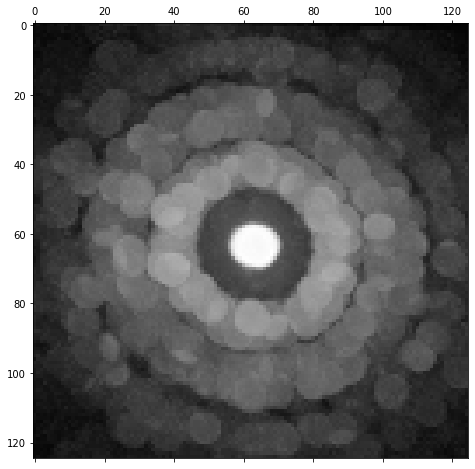

In [13]:
# Examine the 4D dataset - max dark field
DP_max = np.max(data4D.data,axis=(0,1))
py4DSTEM.visualize.show(DP_max,scaling='log')

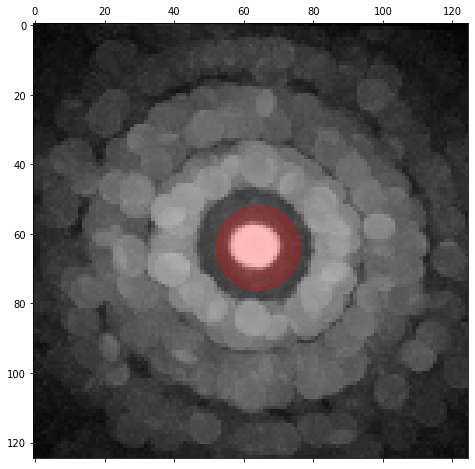

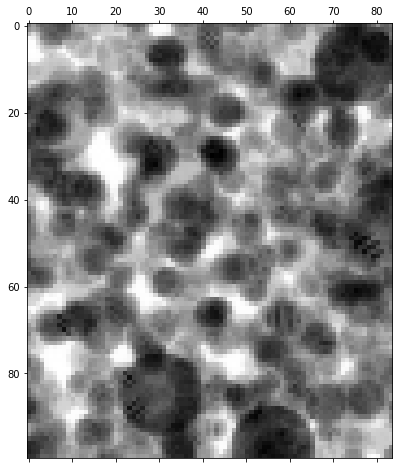

In [14]:
# Bright-field image
qx0,qy0 = 64,64
qR = 12
py4DSTEM.visualize.show_circles(DP_max,center=(qx0,qy0),R=qR,alpha=0.25,scaling='log')
BF_im = py4DSTEM.process.virtualimage.get_virtualimage_circ(data4D,qx0,qy0,qR)
py4DSTEM.visualize.show(BF_im)

In [23]:
# Open the 4D data browser

py4DSTEM.visualize.vis_interactive.browse4D(data4D)

In [8]:
%matplotlib notebook
py4DSTEM.visualize.vis_interactive.browse4D(data4D)

In [25]:
BrushIntervalSelector?

Object `BrushIntervalSelector` not found.


In [ ]:
from ipywidgets import *
from traitlets import dlink

In [ ]:
def f(x):
    print(x ** x)

In [ ]:
interact(f, x=(0,10));

In [10]:
%matplotlib inline
from ipywidgets import interactive
import numpy as np

def f(m, b, N):
    plt.figure(2)
    x = np.linspace(-10, 10, num=1000)
    plt.plot(x, m * (x ** N) + b)
    plt.xlim(-10, 10)
    plt.ylim(-5, 5)
    plt.show()
    
interactive_plot = interactive(f, m=(-2.0, 2.0, 0.01), b=(-3, 3, 0.01), N=(0,4, 1))
output = interactive_plot.children[-1]
output.layout.height = '300 px'
interactive_plot

interactive(children=(FloatSlider(value=0.0, description='m', max=2.0, min=-2.0, step=0.01), FloatSlider(value…